# Lab | Advanced Tableau Visualization — Python equivalent

Companion to [`tableau-lab-advanced.twbx`](tableau-lab-advanced.twbx): the same
three advanced views, rebuilt so the underlying numbers are reproducible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

df = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/we_fn_use_c_marketing_customer_value_analysis.csv")
df.shape

(9134, 24)

## 1. Choropleth — customers by state

In [2]:
state = df["State"].value_counts()
print(state)
print("\nStates present:", df["State"].nunique(), "of 50")

State
California    3150
Oregon        2601
Arizona       1703
Nevada         882
Washington     798
Name: count, dtype: int64

States present: 5 of 50


The map is the weakest of the three views here, and it's worth being honest
about why: only 5 of 50 states have any data, so a full-US choropleth is 90%
empty. Blank states read as "zero customers" when they actually mean "not in
this dataset" — a real risk of misleading the reader. Zooming to the region, or
keeping the treemap for the comparison, is the better call.

## 2. Regression plot — Customer Lifetime Value vs. Income

In [3]:
r, p = stats.pearsonr(df["Income"], df["Customer Lifetime Value"])
print(f"Pearson r = {r:.4f}   p = {p:.4f}   r^2 = {r**2:.5f}   n = {len(df):,}")
print("zero-income rows:", (df["Income"] == 0).sum())

Pearson r = 0.0244   p = 0.0199   r^2 = 0.00059   n = 9,134
zero-income rows: 2317


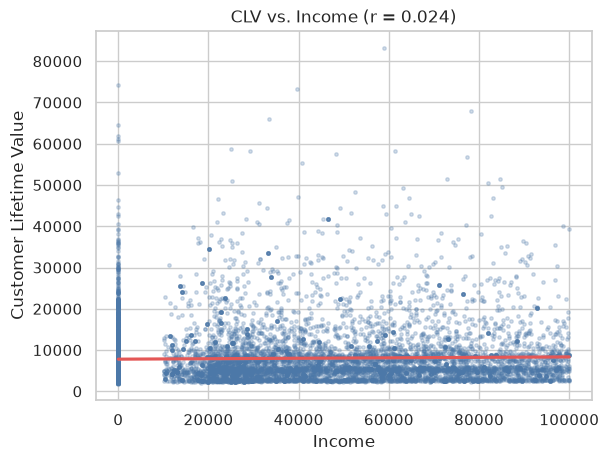

In [4]:
ax = sns.regplot(data=df, x="Income", y="Customer Lifetime Value",
                 scatter_kws=dict(s=6, alpha=0.25, color="#4C78A8"),
                 line_kws=dict(color="#E45756"))
ax.set(title=f"CLV vs. Income (r = {r:.3f})")
plt.show()

**The whole lesson of this lab is in this chart.** p ≈ 0.02 clears the
usual 0.05 bar, so the relationship is "statistically significant" — and r ≈
0.024 means income explains about **0.06%** of the variance in lifetime value.
With n = 9,134, significance is nearly free; it says the slope probably isn't
exactly zero, not that it's useful.

The correct write-up is *"income does not predict customer lifetime value in
this data"*. Reporting it as "a slight positive relationship" because the
p-value cooperated is exactly the mistake the day 4 class warned about.

Note also the vertical stripe at x = 0: 2,317 customers have zero income
(the unemployed), which is a distinct sub-population sitting on the y-axis.

In [5]:
# Does the relationship survive dropping the zero-income block?
earners = df[df["Income"] > 0]
r2, p2 = stats.pearsonr(earners["Income"], earners["Customer Lifetime Value"])
print(f"income > 0 only: n = {len(earners):,}  r = {r2:.4f}  p = {p2:.4f}")

income > 0 only: n = 6,817  r = 0.0029  p = 0.8098


## 3. Boxplot — Total Claim Amount by Vehicle Size

In [6]:
summary = df.groupby("Vehicle Size")["Total Claim Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]).round(2)
summary = summary.sort_values("mean", ascending=False)
display(summary)

,count,mean,median,std,min,max
Vehicle Size,,,,,,
Small,1764,489.43,451.20,272.01,1.84,2327.17
Large,946,426.06,378.26,302.62,0.89,2452.89
Medsize,6424,420.08,362.90,291.83,0.10,2893.24


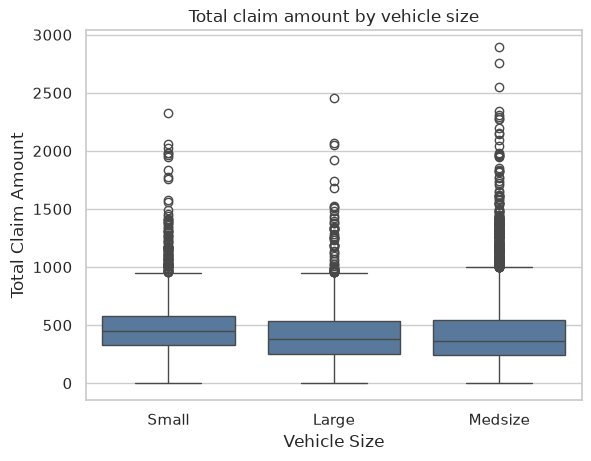

In [7]:
ax = sns.boxplot(data=df, x="Vehicle Size", y="Total Claim Amount",
                 order=summary.index, color="#4C78A8")
ax.set(title="Total claim amount by vehicle size")
plt.show()

Two things to read off it:

- **Small vehicles carry the highest claims** (mean 489 vs. 426 Large and 420
  Medsize) — counter-intuitive, and the most reportable finding in the lab.
- **Every** category has mean > median with a long upper whisker: claim amounts
  are right-skewed, the same shape the day 4 normality work was about.

Medsize is 70% of the rows, so it dominates the eye while being the *lowest* of
the three on both mean and median — a good example of visual weight not matching
the finding.

In [8]:
# Is the Small-vehicle gap statistically real, or just the small-n category?
small = df.loc[df["Vehicle Size"] == "Small", "Total Claim Amount"]
rest = df.loc[df["Vehicle Size"] != "Small", "Total Claim Amount"]
t, p = stats.ttest_ind(small, rest, equal_var=False)
print(f"Welch t = {t:.2f}  p = {p:.2e}")
print(f"mean Small = {small.mean():.2f}   mean rest = {rest.mean():.2f}"
      f"   difference = {small.mean() - rest.mean():.2f}")

Welch t = 9.37  p = 1.48e-20
mean Small = 489.43   mean rest = 420.84   difference = 68.58


Unlike the CLV/Income result, this one is significant *and* sizeable — a
~68 unit gap on a mean of ~420 is a 16% difference, which is worth acting on.
Same statistical machinery, opposite conclusion; the effect size is what
separates them.

## 4 & 5. Dashboard and story

Tableau-only steps. The story structure used in the workbook:

1. *Small vehicles carry the highest average claims* — the actionable finding.
2. *Income doesn't predict lifetime value* — a negative result, stated plainly.
3. *The customer base is five states, not a country* — context and a caveat.